In [2]:
import pandas as pd
df = pd.read_csv('../test/question_type_classification_answer_windturbine_lamma.csv')

In [10]:
dist = {}
import re

dist['Verification'] = 0
dist['Disjunctive'] = 0
dist['Concept'] = 0
dist['Extent'] = 0
dist['Example'] = 0
dist['Comparision'] = 0
dist['Cause'] = 0
dist['Consequence'] = 0
dist['Procedural'] = 0
dist['Judgmental'] = 0

for item in df['final_answer'].to_list():
    splt = re.split("[ ,.]+", item)
    for it in splt:
        if it in dist.keys():
            dist[it] = dist[it] + 1

print (dist)

{'Verification': 308, 'Disjunctive': 2, 'Concept': 1632, 'Extent': 543, 'Example': 521, 'Comparision': 4, 'Cause': 426, 'Consequence': 217, 'Procedural': 1343, 'Judgmental': 3}


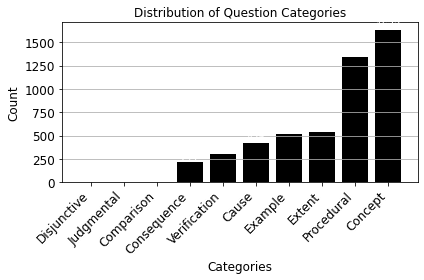

In [21]:
import matplotlib.pyplot as plt

data = {'Verification': 308, 'Disjunctive': 2, 'Concept': 1632, 'Extent': 543, 'Example': 521, 'Comparison': 4, 'Cause': 426, 'Consequence': 217, 'Procedural': 1343, 'Judgmental': 3}

# Sorting categories and corresponding values
sorted_data = sorted(data.items(), key=lambda x: x[1])

# Extracting sorted data for plotting
categories, values = zip(*sorted_data)

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(categories, values, color='black')  # Change color to black
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Question Categories', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels and increase font size
plt.yticks(fontsize=12)  # Increase y-axis font size
plt.grid(axis='y')

# Display the count on each bar with increased font size
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom', fontsize=10, color='white')  # White text on black bars

plt.tight_layout()
plt.savefig('distribution_plot.png')

plt.show()



In [26]:
def callme(node='component'):
    taxonomy = {
        'asset health': ['component', 'historical record', 'asset profile'],
        'component': ['mechanical issue', 'electrical issue', 'thermal health issue', 'chemical health issue'],
        'mechanical issue': ['on-demand inspection', 'continuous sensors', 'periodic chemical sampling'],
        'electrical issue': ['insulin'],
        'historical record': ['asset maintenance', 'failure', 'repair history'],
        'asset profile': ['age', 'operating hours', 'idle hours'],
    }

    def traverse(node):
        if node in taxonomy:
            for child in taxonomy[node]:
                if 'sensor' in child:
                    return "yes it is there"
                else:
                    result = traverse(child)
                    if result != "skip":
                        return result
        else:
            return "skip"

    return traverse(node)

callme('insulin')

'skip'

In [27]:
ans = """
# Think: My target is asset ...

Step 1: Let us focus ....

# Think: Now that ....

Step 2: Collect ....

# Think: We now shift our focus.....

Step 3: Let us assume that ....

Step 4: Great, this answer is an ....

Step 5: We need to be very specific ....

Step 6: Generate a Python code that takes ....
"""

In [35]:
import re
text = ans 

# Remove lines starting with "# Think:"
cleaned_text = re.sub(r'# Think:.*\n', '', text)

# Use regular expression to find all steps and their content
pattern = re.compile(r'(Step \d+:.*?)(?=Step \d+:|$)', re.DOTALL)
matches = pattern.findall(cleaned_text)

# Resulting list of steps and their content
steps_list = [step.strip() for step in matches]

# Display the list of steps
for step in steps_list:
    print(step)

Step 1: Let us focus ....
Step 2: Collect ....
Step 3: Let us assume that ....
Step 4: Great, this answer is an ....
Step 5: We need to be very specific ....
Step 6: Generate a Python code that takes ....


In [ ]:
def callme(node='asset component'):
    taxonomy = {
        'asset health': {
            'analyzed by': {
                'component': {},
                'historical record': {},
                'asset profile': {}
            }
        },
        'component': {
            'impacted by': {
                'mechanical issue': {
                    'measured by': {
                        'on-demand inspection': {},
                        'continuous sensors': {},
                        'periodic chemical sampling': {}
                    }
                },
                'electrical issue': {
                    'measured by': {'insulin': {}}
                },
                'thermal health issue': {},
                'chemical health issue': {}
            }
        },
        'historical record': {
            'source by': {
                'asset maintenance': {},
                'failure': {},
                'repair history': {}
            }
        },
        'asset profile': {
            'recorded by': {
                'age': {},
                'operating hours': {},
                'idle hours': {}
            }
        }
    }

    def traverse(node, word):
        if node == '':
            return False
        elif node.endswith(word):
            return True
        for child in node.split(' '):
            if traverse(child, word):
                return True
        return False

    if node in taxonomy:
        if 'sensor' in traverse(node, 'measured by') or 'sensor' in traverse(node, 'measured'):
            return "yes it is there"
        else:
            return "skip"
    else:
        return "skip"

In [11]:
def callme(node='asset component'):
    """
    This function takes an input node from taxonomy and returns "yes it is there" if any
    child node including the input node has a word sensor into their name otherwise it returns skip.
    """
    taxonomy = {
        'asset health': ['component', 'historical record', 'asset profile'],
        'component': ['mechanical issue', 'electrical issue', 'thermal health issue', 'chemical health issue'],
        'mechanical issue': ['on-demand inspection', 'continuous sensors', 'periodic chemical sampling'],
        'electrical issue': ['insulin'],
        'historical record': ['asset maintenance', 'failure', 'repair history'],
        'asset profile': ['age', 'operating hours', 'idle hours'],
    }

    def _check_node(node, word='sensor'):
        """
        This function checks if the given node or any of its child node has the given word in their name.
        """
        if node in taxonomy:
            print (node)
            if word in node:
                return "yes it is there"
            else:
                for child in taxonomy[node]:
                    #print(child)
                    result = _check_node(child, word)
                    if result == "yes it is there":
                        return "yes it is there"
        return "skip"

    return _check_node(node)

In [12]:
callme(node='component')

component
mechanical issue
electrical issue


'skip'